In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the company workbook
file_path = "../data/raw/company_sales.xlsx"

sales_raw = pd.read_excel(file_path, sheet_name="Sales Data")
people = pd.read_excel(file_path, sheet_name="People")

# Make sure Close Date is treated as a date
sales_raw["Close Date"] = pd.to_datetime(sales_raw["Close Date"])

print("Sales rows:", len(sales_raw))
print("People rows:", len(people))

Sales rows: 435
People rows: 9


In [3]:
# Remove only exact duplicate rows identified during data understanding
sales = sales_raw.drop_duplicates().copy()

print("Rows after removing exact duplicates:", len(sales))

Rows after removing exact duplicates: 383


In [4]:
# One opportunity can contain multiple product-family rows.
# Add those rows together to get the total value of each opportunity.

opportunity_value = (
    sales
    .groupby("Opportunity ID")["Total Price"]
    .sum()
    .reset_index(name="Opportunity Value")
)

opportunity_value.head()

,Opportunity ID,Opportunity Value
0,0061Y00000QA0nIxRU,110225.97
1,0061Y00000QA0nIxXH,16923.58
2,0061Y00000QA0nJ1PR,139373.00
3,0061Y00000QA0nJ6NX,16102.80
4,0061Y00000QA0nUpUC,34948.19


In [5]:
# These fields describe the opportunity itself.
# We confirmed earlier that they are consistent within each Opportunity ID.

opportunity_attributes = (
    sales
    .groupby("Opportunity ID")
    .agg({
        "Opp Owner User ID": "first",
        "Opp Owner Geo": "first",
        "Segment": "first",
        "Opportunity Type": "first",
        "Close Date": "first"
    })
    .reset_index()
)

opportunity_attributes.head()

,Opportunity ID,Opp Owner User ID,Opp Owner Geo,Segment,Opportunity Type,Close Date
0,0061Y00000QA0nIxRU,0054z00000AAVA1E0V,AMER,Enterprise,New Business,2019-09-06
1,0061Y00000QA0nIxXH,0054z00000AAFA1E0p,AMER,Enterprise,Upsell,2019-04-12
2,0061Y00000QA0nJ1PR,0051Y00000QAVBgScR,AMER,Corporate,New Business,2019-03-25
3,0061Y00000QA0nJ6NX,0054z00000AAJA0qTj,AMER,Corporate,Upsell,2019-03-22
4,0061Y00000QA0nUpUC,0054z00000AAVA1E0V,AMER,Enterprise,Upsell,2019-05-06


In [6]:
# Combine opportunity characteristics with total opportunity value.

opportunities = opportunity_attributes.merge(
    opportunity_value,
    on="Opportunity ID",
    how="left"
)

print("Number of opportunities:", len(opportunities))

Number of opportunities: 145


In [7]:
# Match the owner ID to the People table.
# Left join keeps every opportunity even if the name is missing.

opportunities = opportunities.merge(
    people,
    on="Opp Owner User ID",
    how="left"
)

opportunities.head()

,Opportunity ID,Opp Owner User ID,Opp Owner Geo,Segment,Opportunity Type,Close Date,Opportunity Value,Name
0,0061Y00000QA0nIxRU,0054z00000AAVA1E0V,AMER,Enterprise,New Business,2019-09-06,110225.97,Alice Chen
1,0061Y00000QA0nIxXH,0054z00000AAFA1E0p,AMER,Enterprise,Upsell,2019-04-12,16923.58,Bob Smith
2,0061Y00000QA0nJ1PR,0051Y00000QAVBgScR,AMER,Corporate,New Business,2019-03-25,139373.00,Charlie Day
3,0061Y00000QA0nJ6NX,0054z00000AAJA0qTj,AMER,Corporate,Upsell,2019-03-22,16102.80,Diana Prince
4,0061Y00000QA0nUpUC,0054z00000AAVA1E0V,AMER,Enterprise,Upsell,2019-05-06,34948.19,Alice Chen


In [8]:
# Start by understanding the size of the business represented in the dataset.

total_value = opportunities["Opportunity Value"].sum()
number_of_opportunities = opportunities["Opportunity ID"].nunique()
average_value = opportunities["Opportunity Value"].mean()
median_value = opportunities["Opportunity Value"].median()

print(f"Total recorded value: ${total_value:,.2f}")
print(f"Number of opportunities: {number_of_opportunities}")
print(f"Average opportunity value: ${average_value:,.2f}")
print(f"Median opportunity value: ${median_value:,.2f}")

Total recorded value: $7,071,744.49
Number of opportunities: 145
Average opportunity value: $48,770.65
Median opportunity value: $21,259.10


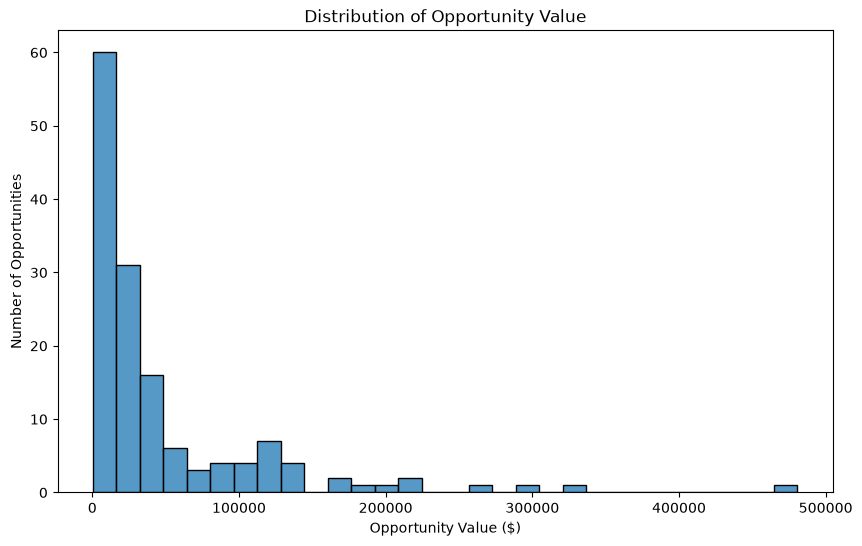

In [9]:
# Look at how opportunity values are distributed.

plt.figure(figsize=(10, 6))

sns.histplot(
    opportunities["Opportunity Value"],
    bins=30
)

plt.title("Distribution of Opportunity Value")
plt.xlabel("Opportunity Value ($)")
plt.ylabel("Number of Opportunities")

plt.show()

In [10]:
# Find the largest opportunities in the dataset.

top_opportunities = (
    opportunities
    .sort_values("Opportunity Value", ascending=False)
    .head(10)
)

top_opportunities[
    [
        "Opportunity ID",
        "Name",
        "Opp Owner Geo",
        "Segment",
        "Opportunity Type",
        "Opportunity Value"
    ]
]

,Opportunity ID,Name,Opp Owner Geo,Segment,Opportunity Type,Opportunity Value
89,0061Y00000QA2s2TGG,NaN,EMEA,Enterprise,Upsell,480718.00
38,0061Y00000QA0rH1FY,NaN,EMEA,Enterprise,New Business,333688.18
19,0061Y00000QA0pP9QQ,Hannah Abbott,APAC,Enterprise,Upsell,289482.34
71,0061Y00000QA2rzGGS,NaN,EMEA,Enterprise,Upsell,271503.09
15,0061Y00000QA0pOeLI,NaN,AMER,Enterprise,Upsell,223660.16
109,0061Y00000QA2slLHN,NaN,EMEA,Enterprise,Upsell,211990.14
128,0061Y00000QA2ttZJY,NaN,EMEA,Enterprise,New Business,196287.16
29,0061Y00000QA0qYxDS,George Bluth,AMER,Enterprise,Upsell,178142.98
67,0061Y00000QA2orQEZ,George Bluth,AMER,Enterprise,Upsell,167908.00
118,0061Y00000QA2smSSW,NaN,EMEA,Enterprise,Upsell,164947.20


In [11]:
# Understand which Product Lines contribute the most value.

product_line = (
    sales
    .groupby("Product Line")
    .agg(
        Total_Value=("Total Price", "sum"),
        Records=("Opportunity ID", "count"),
        Opportunities=("Opportunity ID", "nunique")
    )
    .reset_index()
    .sort_values("Total_Value", ascending=False)
)

product_line

,Product Line,Total_Value,Records,Opportunities
1,Workforce,5303947.20,346,132
0,CIAM,1767797.29,37,14


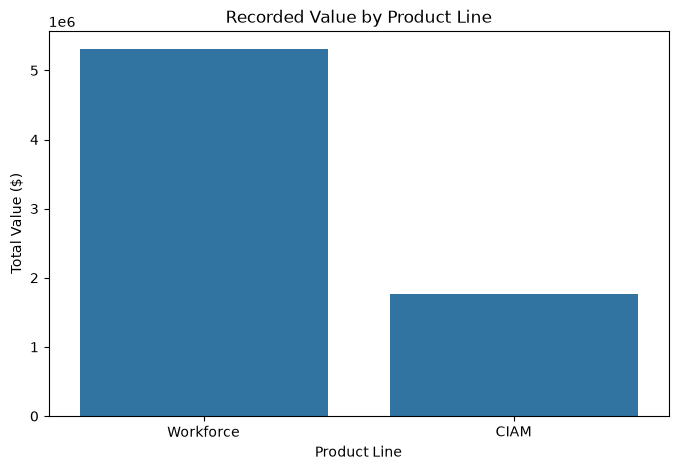

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=product_line,
    x="Product Line",
    y="Total_Value"
)

plt.title("Recorded Value by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Value ($)")

plt.show()

In [13]:
# Go one level deeper than Product Line.

product_family = (
    sales
    .groupby("Product Family")
    .agg(
        Total_Value=("Total Price", "sum"),
        Records=("Opportunity ID", "count"),
        Opportunities=("Opportunity ID", "nunique")
    )
    .reset_index()
    .sort_values("Total_Value", ascending=False)
)

product_family

,Product Family,Total_Value,Records,Opportunities
2,Workforce - B,1956893.79,89,89
3,Workforce - C,1874967.37,100,81
0,CIAM - A,1767797.29,37,14
1,Workforce - A,1049645.25,147,102
4,Workforce - D,357391.85,3,3
5,Workforce - E,65048.94,7,7


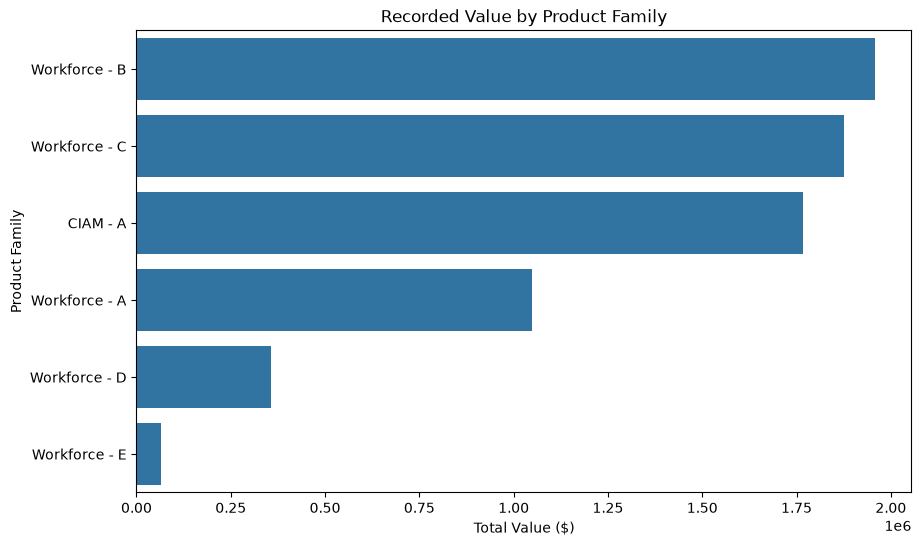

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=product_family,
    x="Total_Value",
    y="Product Family"
)

plt.title("Recorded Value by Product Family")
plt.xlabel("Total Value ($)")
plt.ylabel("Product Family")

plt.show()

In [15]:
segment = (
    opportunities
    .groupby("Segment")
    .agg(
        Total_Value=("Opportunity Value", "sum"),
        Opportunities=("Opportunity ID", "nunique"),
        Average_Deal=("Opportunity Value", "mean"),
        Median_Deal=("Opportunity Value", "median")
    )
    .reset_index()
)

segment

,Segment,Total_Value,Opportunities,Average_Deal,Median_Deal
0,Corporate,1781335.24,87,20475.117701,15336.000
1,Enterprise,5290409.25,58,91213.952586,62756.225


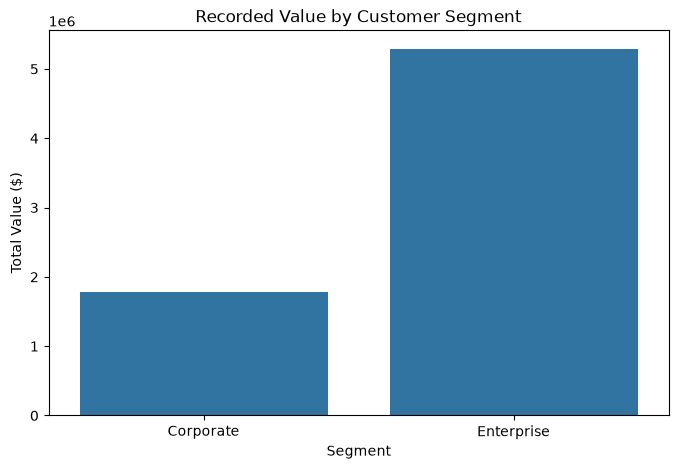

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment,
    x="Segment",
    y="Total_Value"
)

plt.title("Recorded Value by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Value ($)")

plt.show()

In [17]:
segment = (
    opportunities
    .groupby("Segment")
    .agg(
        Total_Value=("Opportunity Value", "sum"),
        Opportunities=("Opportunity ID", "nunique"),
        Average_Deal=("Opportunity Value", "mean"),
        Median_Deal=("Opportunity Value", "median")
    )
    .reset_index()
)

segment

,Segment,Total_Value,Opportunities,Average_Deal,Median_Deal
0,Corporate,1781335.24,87,20475.117701,15336.000
1,Enterprise,5290409.25,58,91213.952586,62756.225


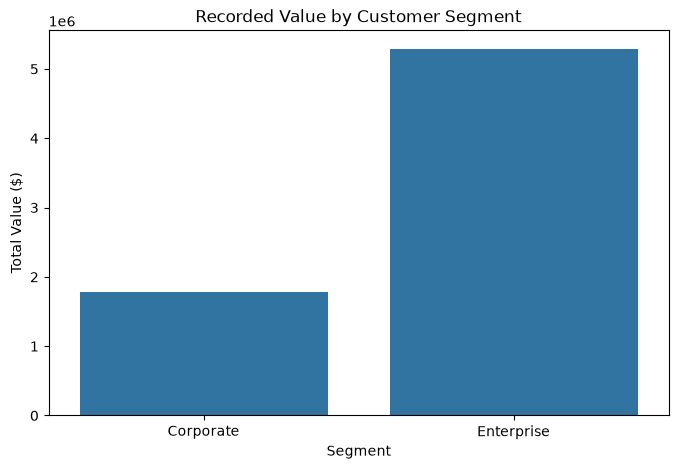

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment,
    x="Segment",
    y="Total_Value"
)

plt.title("Recorded Value by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Value ($)")

plt.show()

In [19]:
# This is Opp Owner Geo, so interpret it as geography associated
# with the opportunity owner, not confirmed customer geography.

geography = (
    opportunities
    .groupby("Opp Owner Geo")
    .agg(
        Total_Value=("Opportunity Value", "sum"),
        Opportunities=("Opportunity ID", "nunique"),
        Average_Deal=("Opportunity Value", "mean"),
        Median_Deal=("Opportunity Value", "median")
    )
    .reset_index()
)

geography

,Opp Owner Geo,Total_Value,Opportunities,Average_Deal,Median_Deal
0,AMER,2504290.71,44,56915.697955,34028.61
1,APAC,1042607.51,27,38615.092963,17339.62
2,EMEA,3524846.27,74,47633.057703,19663.65


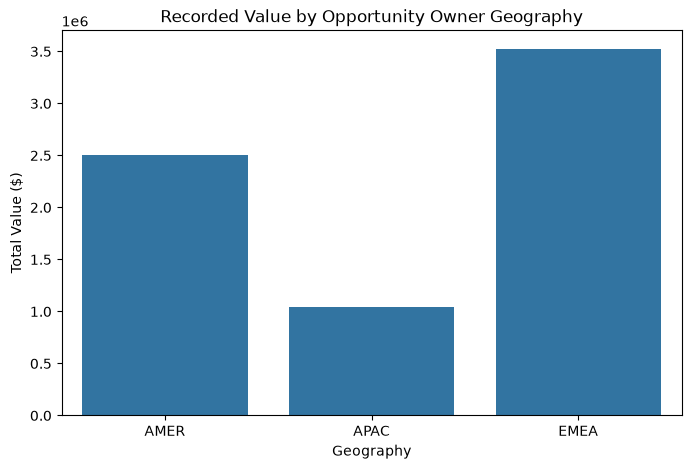

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=geography,
    x="Opp Owner Geo",
    y="Total_Value"
)

plt.title("Recorded Value by Opportunity Owner Geography")
plt.xlabel("Geography")
plt.ylabel("Total Value ($)")

plt.show()

In [22]:
opportunity_type = (
    opportunities
    .groupby("Opportunity Type")
    .agg(
        Total_Value=("Opportunity Value", "sum"),
        Opportunities=("Opportunity ID", "nunique"),
        Average_Deal=("Opportunity Value", "mean"),
        Median_Deal=("Opportunity Value", "median")
    )
    .reset_index()
)

opportunity_type

,Opportunity Type,Total_Value,Opportunities,Average_Deal,Median_Deal
0,New Business,2435735.77,43,56645.017907,31201.660
1,Upsell,4636008.72,102,45451.065882,18638.355


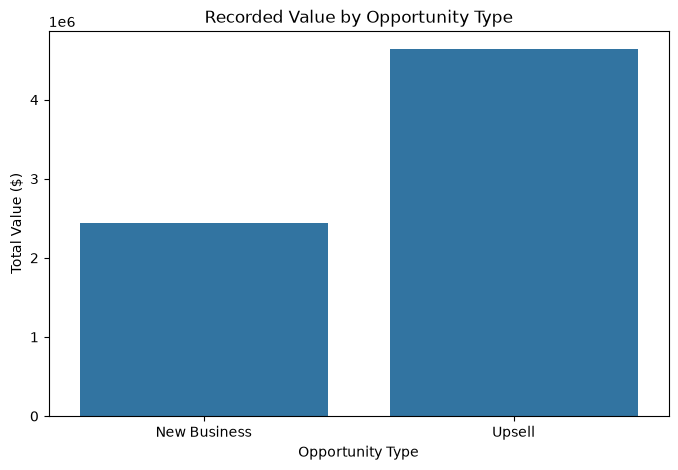

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=opportunity_type,
    x="Opportunity Type",
    y="Total_Value"
)

plt.title("Recorded Value by Opportunity Type")
plt.xlabel("Opportunity Type")
plt.ylabel("Total Value ($)")

plt.show()

In [24]:
# Which products are strongest within each customer segment?

product_segment = (
    sales
    .groupby(["Product Line", "Segment"])["Total Price"]
    .sum()
    .reset_index(name="Total_Value")
)

product_segment

,Product Line,Segment,Total_Value
0,CIAM,Corporate,254327.68
1,CIAM,Enterprise,1513469.61
2,Workforce,Corporate,1527007.56
3,Workforce,Enterprise,3776939.64


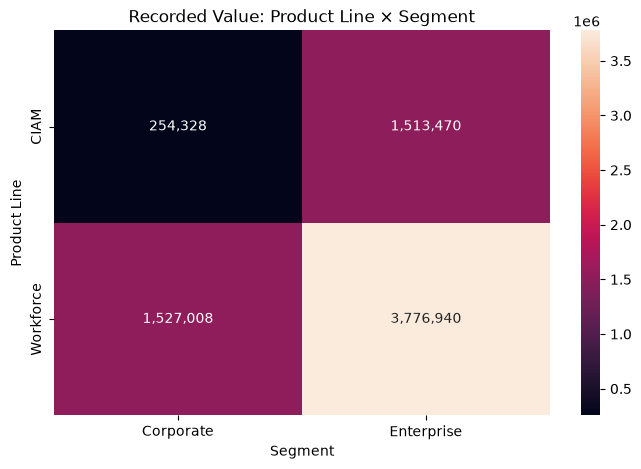

In [25]:
# Make the comparison easier to see.

pivot = product_segment.pivot(
    index="Product Line",
    columns="Segment",
    values="Total_Value"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=",.0f"
)

plt.title("Recorded Value: Product Line × Segment")
plt.xlabel("Segment")
plt.ylabel("Product Line")

plt.show()

In [26]:
# Which products are strongest across different owner geographies?

product_geo = (
    sales
    .groupby(["Product Line", "Opp Owner Geo"])["Total Price"]
    .sum()
    .reset_index(name="Total_Value")
)

product_geo

,Product Line,Opp Owner Geo,Total_Value
0,CIAM,AMER,467453.50
1,CIAM,APAC,171972.65
2,CIAM,EMEA,1128371.14
3,Workforce,AMER,2036837.21
4,Workforce,APAC,870634.86
5,Workforce,EMEA,2396475.13


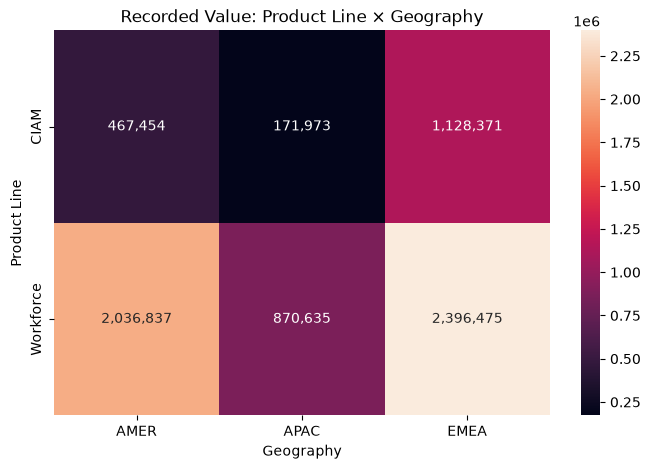

In [27]:
pivot_geo = product_geo.pivot(
    index="Product Line",
    columns="Opp Owner Geo",
    values="Total_Value"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    pivot_geo,
    annot=True,
    fmt=",.0f"
)

plt.title("Recorded Value: Product Line × Geography")
plt.xlabel("Geography")
plt.ylabel("Product Line")

plt.show()

In [28]:
# This is the most detailed market combination we have.

product_market = (
    sales
    .groupby([
        "Product Line",
        "Segment",
        "Opp Owner Geo"
    ])["Total Price"]
    .sum()
    .reset_index(name="Total_Value")
    .sort_values("Total_Value", ascending=False)
)

product_market

,Product Line,Segment,Opp Owner Geo,Total_Value
8,Workforce,Enterprise,AMER,1710494.21
10,Workforce,Enterprise,EMEA,1536824.71
4,CIAM,Enterprise,EMEA,907271.46
7,Workforce,Corporate,EMEA,859650.42
9,Workforce,Enterprise,APAC,529620.72
2,CIAM,Enterprise,AMER,467453.50
6,Workforce,Corporate,APAC,341014.14
5,Workforce,Corporate,AMER,326343.00
1,CIAM,Corporate,EMEA,221099.68
3,CIAM,Enterprise,APAC,138744.65


In [29]:
# Create simple time fields so we can study changes over time.

opportunities["Year"] = opportunities["Close Date"].dt.year
opportunities["Quarter"] = opportunities["Close Date"].dt.quarter
opportunities["Month"] = opportunities["Close Date"].dt.month

In [30]:
yearly = (
    opportunities
    .groupby("Year")
    .agg(
        Total_Value=("Opportunity Value", "sum"),
        Opportunities=("Opportunity ID", "nunique"),
        Average_Deal=("Opportunity Value", "mean"),
        Median_Deal=("Opportunity Value", "median")
    )
    .reset_index()
)

yearly

,Year,Total_Value,Opportunities,Average_Deal,Median_Deal
0,2019,1822466.98,37,49255.864324,31653.50
1,2020,4692377.06,91,51564.583077,21259.10
2,2021,539895.95,16,33743.496875,18259.92
3,2022,17004.50,1,17004.500000,17004.50


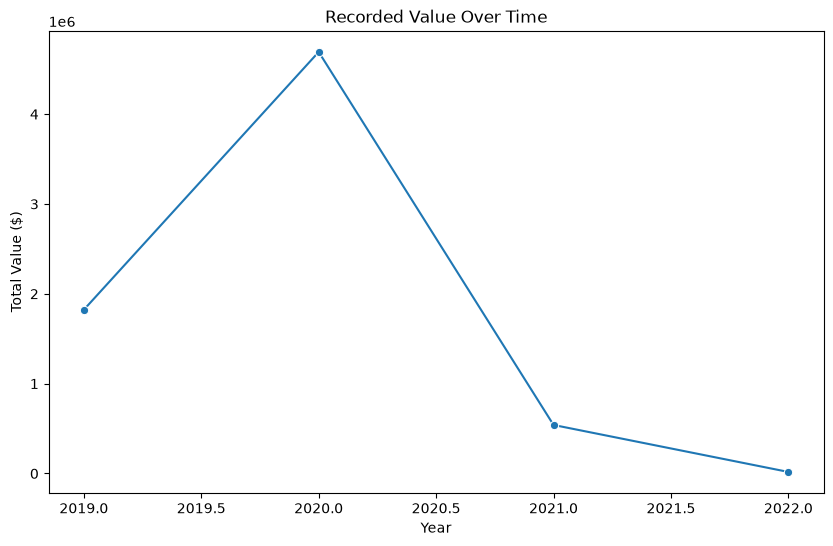

In [31]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=yearly,
    x="Year",
    y="Total_Value",
    marker="o"
)

plt.title("Recorded Value Over Time")
plt.xlabel("Year")
plt.ylabel("Total Value ($)")

plt.show()

In [32]:
# Combine year and quarter so we can see the business more granularly.

quarterly = (
    opportunities
    .groupby(["Year", "Quarter"])
    .agg(
        Total_Value=("Opportunity Value", "sum"),
        Opportunities=("Opportunity ID", "nunique"),
        Average_Deal=("Opportunity Value", "mean")
    )
    .reset_index()
)

quarterly

,Year,Quarter,Total_Value,Opportunities,Average_Deal
0,2019,1,288645.92,7,41235.131429
1,2019,2,408521.05,14,29180.075000
2,2019,3,383808.58,7,54829.797143
3,2019,4,741491.43,9,82387.936667
4,2020,1,1040079.04,21,49527.573333
5,2020,2,1367406.81,21,65114.610000
6,2020,3,1294648.58,27,47949.947407
7,2020,4,990242.63,22,45011.028636
8,2021,1,452249.01,12,37687.417500
9,2021,2,87646.94,4,21911.735000


In [33]:
# Create one compact summary table for the main business dimensions.

summary_tables = {
    "Product Line": product_line,
    "Product Family": product_family,
    "Segment": segment,
    "Geography": geography,
    "Opportunity Type": opportunity_type
}

for name, table in summary_tables.items():
    print(f"\n{'=' * 20} {name} {'=' * 20}")
    display(table)


==================== Product Line ====================


,Product Line,Total_Value,Records,Opportunities
1,Workforce,5303947.20,346,132
0,CIAM,1767797.29,37,14



==================== Product Family ====================


,Product Family,Total_Value,Records,Opportunities
2,Workforce - B,1956893.79,89,89
3,Workforce - C,1874967.37,100,81
0,CIAM - A,1767797.29,37,14
1,Workforce - A,1049645.25,147,102
4,Workforce - D,357391.85,3,3
5,Workforce - E,65048.94,7,7



==================== Segment ====================


,Segment,Total_Value,Opportunities,Average_Deal,Median_Deal
0,Corporate,1781335.24,87,20475.117701,15336.000
1,Enterprise,5290409.25,58,91213.952586,62756.225



==================== Geography ====================


,Opp Owner Geo,Total_Value,Opportunities,Average_Deal,Median_Deal
0,AMER,2504290.71,44,56915.697955,34028.61
1,APAC,1042607.51,27,38615.092963,17339.62
2,EMEA,3524846.27,74,47633.057703,19663.65



==================== Opportunity Type ====================


,Opportunity Type,Total_Value,Opportunities,Average_Deal,Median_Deal
0,New Business,2435735.77,43,56645.017907,31201.660
1,Upsell,4636008.72,102,45451.065882,18638.355


### Analytical Dataset Construction

The analysis established the appropriate analytical grain for the dataset. The original Sales Data contains 435 records representing 145 unique opportunities, with multiple product-family records potentially belonging to the same opportunity. Fifty-two exact duplicate records were identified and removed from the working dataset, reducing the data to 383 records. This reduced the recorded Total Price from $7.61M to $7.07M, a difference of $538,262.35 or 7.07%, demonstrating that duplicate handling is material to downstream analysis. An opportunity-level dataset was constructed containing 145 records, where each row represents one opportunity and includes its total recorded value, owner, geography, segment, opportunity type, close date, and product-family counts. Validation confirmed that Segment, Opp Owner Geo, Opportunity Type, and Close Date are consistent within each opportunity. Both product-level and opportunity-level datasets were retained because they support different analytical questions.